# Literature Material-Role Frequency

Local text-match recount over the locked corpus (`data/corpus.jsonl`, membership defined by `reports/corpus_articles.csv`). Role 1/2/3 material-frequency bars, plus a role-recognition figure: single-role papers per role and the pairwise multi-role overlaps (R1∩R2, R2∩R3, R1∩R3). The locked list contains only papers mentioning ≥1 Role 1/2/3 material (N = 163).

In [1]:
DROP_TITLE_ONLY = True   

import re, sys, csv, json
from collections import Counter
from pathlib import Path
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# Style
mpl.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Liberation Sans", "DejaVu Sans"],
    "mathtext.default": "regular",
    "font.size": 14,
    "axes.titlesize": 12,
    "axes.titleweight": "bold",
    "axes.labelsize": 14,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 12,
    "figure.dpi": 150,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
    "axes.linewidth": 0.8,
    "pdf.fonttype": 42, "ps.fonttype": 42,
})

# repo root (robust to running from repo root or notebooks/)
REPO = next(base for base in [Path("."), Path("..")] if (base / "reports").exists())
sys.path.insert(0, str(REPO.resolve()))
# lexicon: roles -> materials (regex incl. abbreviations) + per-(material,DOI) collision exclusions
from material_frequency.config import ROLES, RECOGNITION_EXCLUSIONS

VER = "v4" if DROP_TITLE_ONLY else "v3"

def norm_doi(s):
    s = (s or "").strip().lower()
    for pre in ("https://doi.org/", "http://doi.org/", "https://dx.doi.org/", "doi:"):
        s = s.replace(pre, "")
    return s.strip()

def reconstruct_abstract(inv):
    if not inv:
        return ""
    pos = {}
    for w, ps in inv.items():
        for p in ps:
            pos[p] = w
    return " ".join(pos[i] for i in range(max(pos) + 1) if i in pos) if pos else ""

# corpus membership is defined by the locked per-article list; + recovered Springer abstracts
corpus_dois = {norm_doi(r["doi"])
               for r in csv.DictReader(open(REPO / "reports" / "corpus_articles.csv"))}
recovered = json.loads((REPO / "data" / "recovered_abstracts.json").read_text())

# load + filter corpus; attach text = title + abstract (OpenAlex, or recovered for Springer)
papers = []
with open(REPO / "data" / "corpus.jsonl") as f:
    for line in f:
        line = line.strip()
        if not line:
            continue
        d = json.loads(line)
        d["_doi"] = norm_doi(d.get("doi"))
        if d["_doi"] not in corpus_dois:
            continue
        abstract = reconstruct_abstract(d.get("abstract_inverted_index")) or recovered.get(d["id"], "")
        d["_abstract"] = abstract
        d["_text"] = ((d.get("title") or "") + " " + abstract).lower()
        papers.append(d)

if DROP_TITLE_ONLY:                       # v4: keep only abstract-bearing papers
    papers = [p for p in papers if p["_abstract"].strip()]
CORPUS_N = len(papers)
n_title_only = sum(1 for p in papers if not p["_abstract"].strip())

# compile per-material and per-role regex (discover.py::_lexicon_regexes pattern)
materials = []           
role_mats = {}            
for i, (role_label, mats) in enumerate(ROLES):
    role_mats[i] = []
    for m in mats:
        pats = [re.compile(p, re.I) for p in m["regex"]]
        materials.append((role_label, m["key"], m["label"], m["selected"], pats))
        role_mats[i].append((m["key"], pats))

def hit(paper, key, pats):
    """Regex match, minus per-(material, DOI) collision exclusions (see config)."""
    if (key, paper["_doi"]) in RECOGNITION_EXCLUSIONS:
        return False
    return any(rx.search(paper["_text"]) for rx in pats)

# per-material prevalence (overlapping: a paper may mention several materials)
rows = []
for role_label, key, label, selected, pats in materials:
    c = sum(1 for p in papers if hit(p, key, pats))
    rows.append(dict(role=role_label, material=label, key=key, selected=selected,
                     abs_count=c, corpus_n=CORPUS_N,
                     prevalence_pct=round(100 * c / CORPUS_N, 3)))
df = pd.DataFrame(rows).sort_values(["role", "abs_count"], ascending=[True, False]).reset_index(drop=True)

PLOTS = REPO / "plots" / "citation_frequency"; PLOTS.mkdir(parents=True, exist_ok=True)
SELECTED_COLOR = "#1b7837"   # selected building block (GUM / ALG / CMC / PVA)
OTHER_COLOR    = "#bdbdbd"   # candidate considered but not selected

def cap_words(s):
    """Title-case a material name, preserving all-caps acronyms (e.g. SAP)."""
    return re.sub(r"[A-Za-z]+",
                  lambda m: m.group(0) if (m.group(0).isupper() and len(m.group(0)) > 1)
                            else m.group(0)[:1].upper() + m.group(0)[1:].lower(),
                  s)

def plot_role(role_prefix, title, all_muted=False, annotations=None, save=None):
    """Horizontal bar chart of one role's materials, counts descending (verbatim v2)."""
    sub = (df[(df["role"].str.startswith(role_prefix)) & (df["abs_count"] > 0)]
           .sort_values("abs_count", ascending=True))
    colors = [SELECTED_COLOR if (sel and not all_muted) else OTHER_COLOR
              for sel in sub["selected"]]
    fig, ax = plt.subplots(figsize=(8, 0.45 * len(sub) + 1.8))
    bars = ax.barh(sub["material"], sub["abs_count"], color=colors)
    pad = max(max(sub["abs_count"]), 1) * 0.01
    for bar, count, pct in zip(bars, sub["abs_count"], sub["prevalence_pct"]):
        ax.text(bar.get_width() + pad, bar.get_y() + bar.get_height() / 2,
                f"{int(count)}", va="center", ha="left", fontsize=12)
    disp = [cap_words(m) for m in sub["material"]]
    if annotations:
        notes = []
        for i, (label, note) in enumerate(annotations.items()):
            mark = "*" * (i + 1)
            disp = [f"{d} {mark}" if orig == label else d
                    for d, orig in zip(disp, sub["material"])]
            notes.append(f"{mark} {note}")
        fig.text(0.02, -0.02, "\n".join(notes), fontsize=12, style="italic",
                 color="#555", wrap=True)
    ax.set_yticks(range(len(disp)))
    ax.set_yticklabels(disp)
    ax.set_xlabel("Count of Papers")
    ax.set_title(title, fontsize=12, loc="left")
    ax.set_xlim(0, max(max(sub["abs_count"]), 1) * 1.30)
    ax.spines[["top", "right"]].set_visible(False)
    if not all_muted:
        ax.legend(handles=[Patch(color=SELECTED_COLOR, label="Selected Building Block"),
                           Patch(color=OTHER_COLOR, label="Candidate (Not Selected)")],
                  loc="lower right", fontsize=12, frameon=False)
    plt.tight_layout()
    if save:
        fig.savefig(save, format="svg")
    plt.show()

print(f"{VER}: CORPUS_N={CORPUS_N}  title-only-kept={n_title_only}  recovered-abstracts={len(recovered)}")

v4: CORPUS_N=163  title-only-kept=0  recovered-abstracts=74


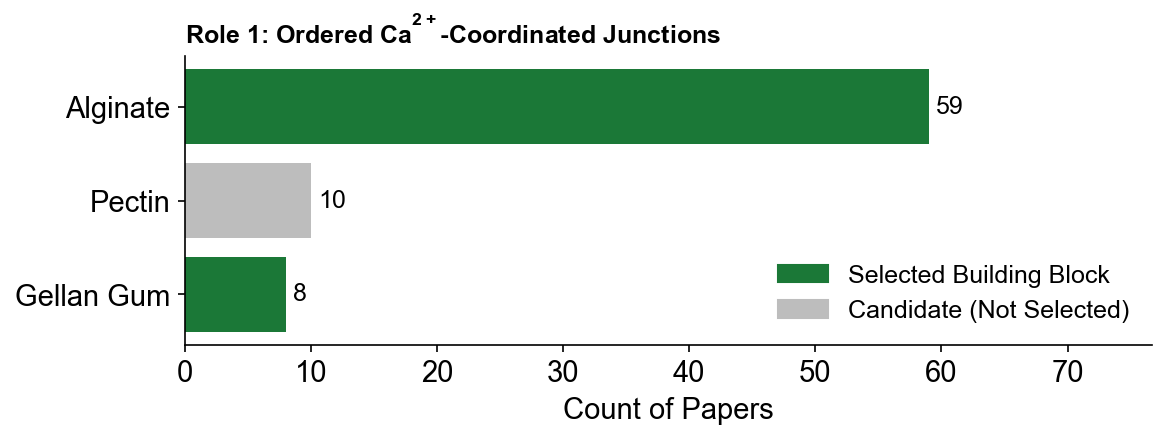

In [2]:
plot_role(
    "Role 1",
    "Role 1: Ordered Ca$^{2+}$-Coordinated Junctions",
    save=str(PLOTS / f"role1_{VER}.svg"),
)

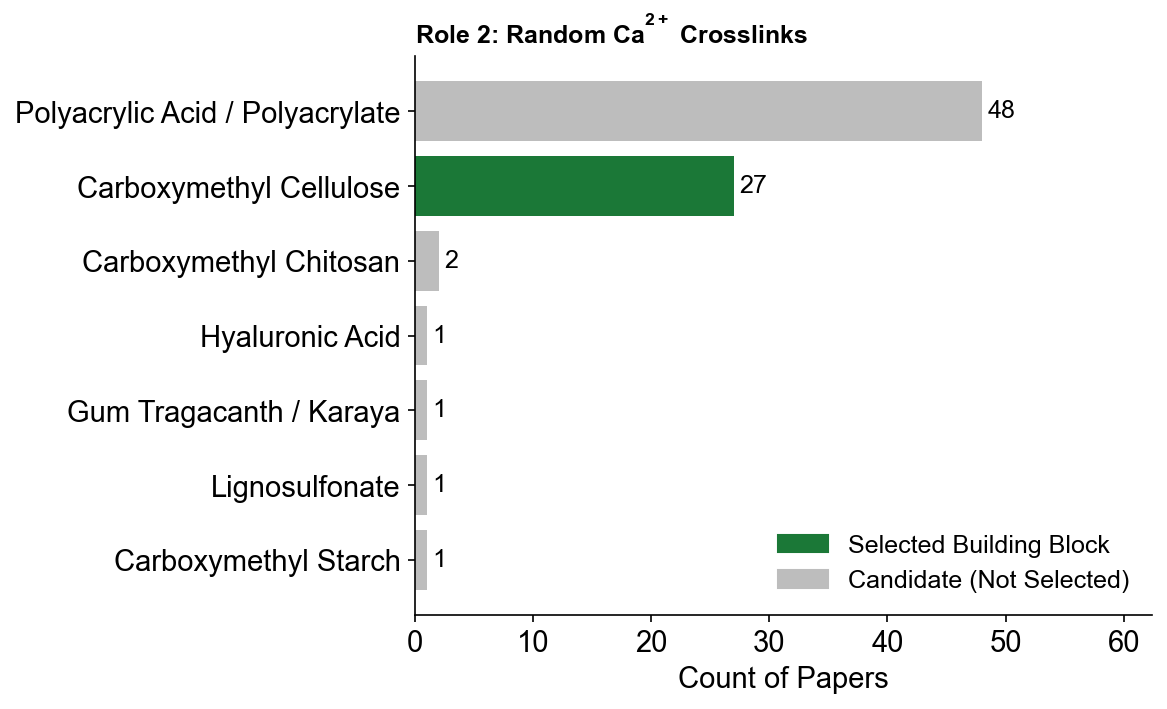

In [3]:
plot_role("Role 2", "Role 2: Random Ca$^{2+}$ Crosslinks",
          save=str(PLOTS / f"role2_{VER}.svg"))

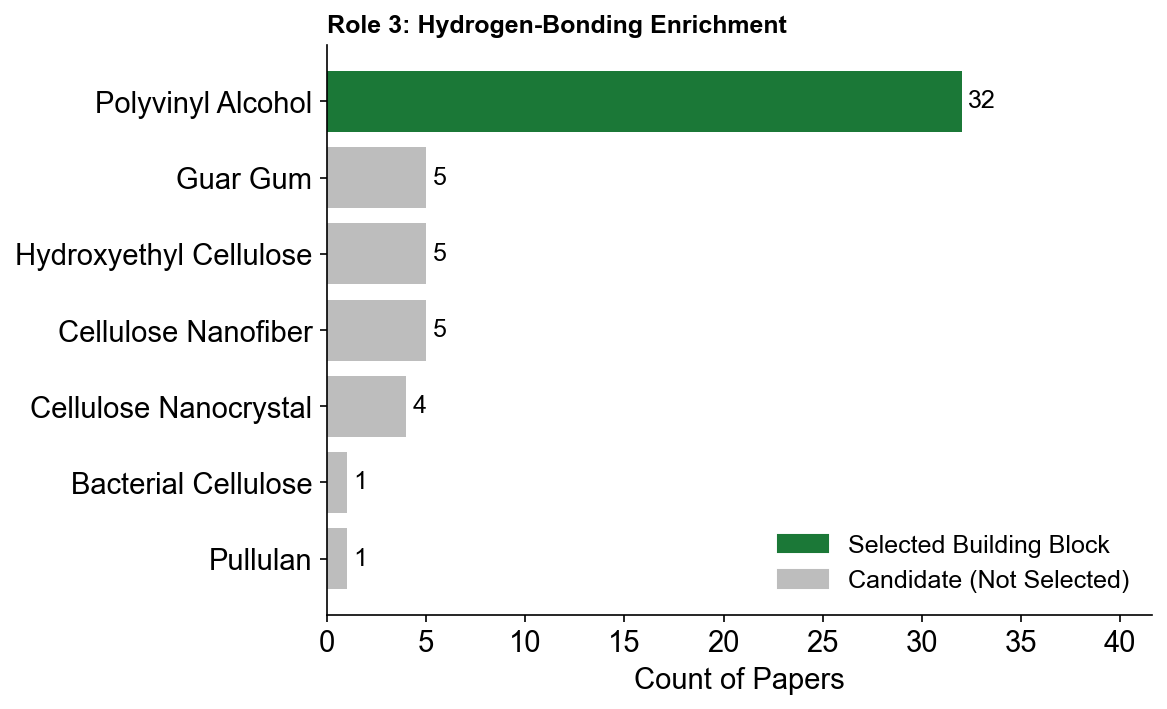

In [4]:
plot_role("Role 3", "Role 3: Hydrogen-Bonding Enrichment",
          save=str(PLOTS / f"role3_{VER}.svg"))

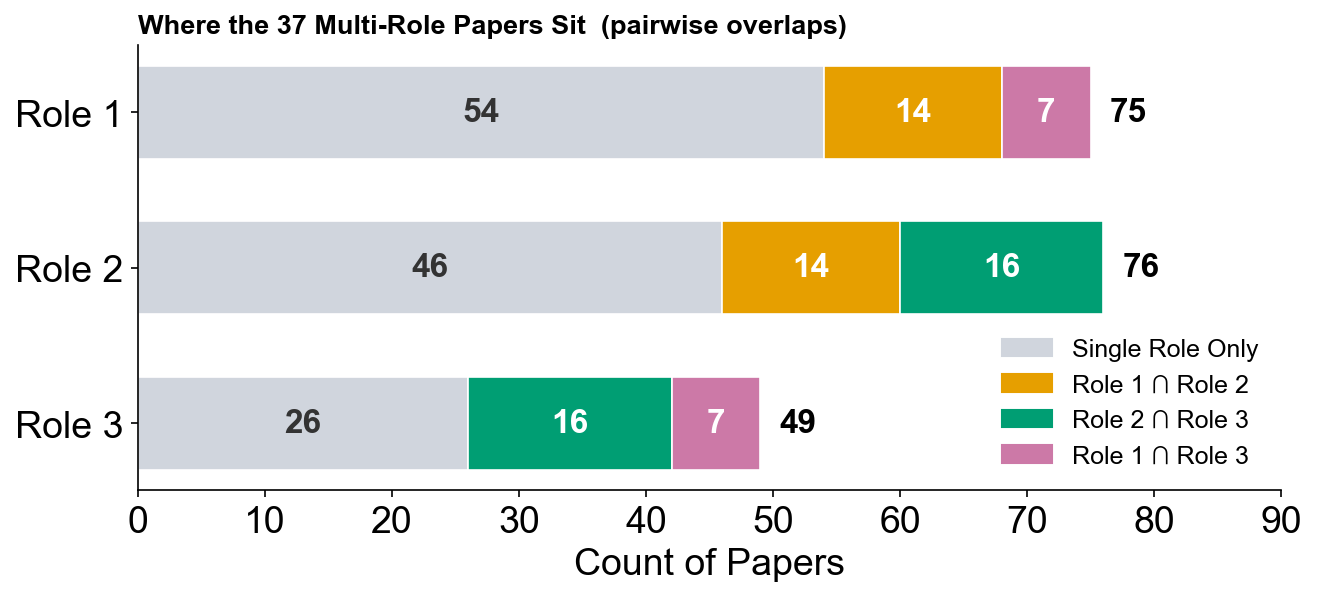

In [5]:
# Final figure — break the "≥2 roles" overlap into its three pairwise intersections.
# Each pair gets its own color that appears in BOTH roles it bridges, so a reader can
# trace, e.g., the 14 orange R1∩R2 papers across the Role 1 and Role 2 bars.
def roles_of(paper):
    return frozenset(b for i, b in [(0, "R1"), (1, "R2"), (2, "R3")]
                     if any(hit(paper, key, pats) for key, pats in role_mats[i]))
sets = [roles_of(p) for p in papers]
reg  = lambda *r: sum(1 for s in sets if s == frozenset(r))
sole = {b: reg(b) for b in ("R1", "R2", "R3")}
P12, P23, P13 = reg("R1", "R2"), reg("R2", "R3"), reg("R1", "R3")

SOLE_C, C12, C23, C13 = "#d0d5dd", "#E69F00", "#009E73", "#CC79A7"   
rows = {
    "Role 1": [(sole["R1"], SOLE_C), (P12, C12), (P13, C13)],
    "Role 2": [(sole["R2"], SOLE_C), (P12, C12), (P23, C23)],
    "Role 3": [(sole["R3"], SOLE_C), (P23, C23), (P13, C13)],
}
order = ["Role 3", "Role 2", "Role 1"]   # bottom -> top

fig, ax = plt.subplots(figsize=(9, 4.2))
for yi, lab in enumerate(order):
    left = 0
    for val, color in rows[lab]:
        if not val:
            continue
        ax.barh(yi, val, left=left, color=color, height=0.6, edgecolor="white", linewidth=0.8)
        ax.text(left + val / 2, yi, str(val), va="center", ha="center",
                color=("#333" if color == SOLE_C else "white"), fontsize=16, fontweight="bold")
        left += val
    ax.text(left + 1.5, yi, str(left), va="center", ha="left", fontsize=16, fontweight="bold")

ax.set_yticks(range(len(order)))
ax.set_yticklabels(order, fontsize=18)
ax.set_xlabel("Count of Papers", fontsize=18)
ax.tick_params(axis="x", labelsize=18)
ax.set_xlim(0, 90)
ax.set_title(f"Where the {P12 + P23 + P13} Multi-Role Papers Sit  (pairwise overlaps)",
             fontsize=13, fontweight="bold", loc="left")
ax.spines[["top", "right"]].set_visible(False)
ax.legend(handles=[Patch(color=SOLE_C, label="Single Role Only"),
                   Patch(color=C12, label=f"Role 1 ∩ Role 2"),
                   Patch(color=C23, label=f"Role 2 ∩ Role 3"),
                   Patch(color=C13, label=f"Role 1 ∩ Role 3")],
          loc="lower right", frameon=False, fontsize=12)
plt.tight_layout()
fig.savefig(PLOTS / f"role_overlap_pairs_{VER}.svg", format="svg")
plt.show()